开始加载数据...

开始训练 XGBoost 模型...
当前 XGBoost 版本不支持 early_stopping_rounds，将使用固定 300 轮迭代。

===== 测试集评估结果 =====
总体指标: MSE=0.000833, RMSE=0.028854, MAE=0.013915, R2=0.992602, Combined=0.000833

各分量详细指标:
CL: RMSE=0.038893, MAE=0.023873, R2=0.990029, MRE=4.5484%
CD: RMSE=0.021726, MAE=0.014768, R2=0.997269, MRE=7.1723%
CN: RMSE=0.046409, MAE=0.026548, R2=0.991678, MRE=3.3475%
CA: RMSE=0.002600, MAE=0.001740, R2=0.988412, MRE=10.1783%
CM: RMSE=0.004194, MAE=0.002646, R2=0.995622, MRE=2.0718%

===== 训练集评估 =====
总体RMSE=0.004810, R2=0.999810

===== 验证集评估 =====
总体RMSE=0.012034, R2=0.998809


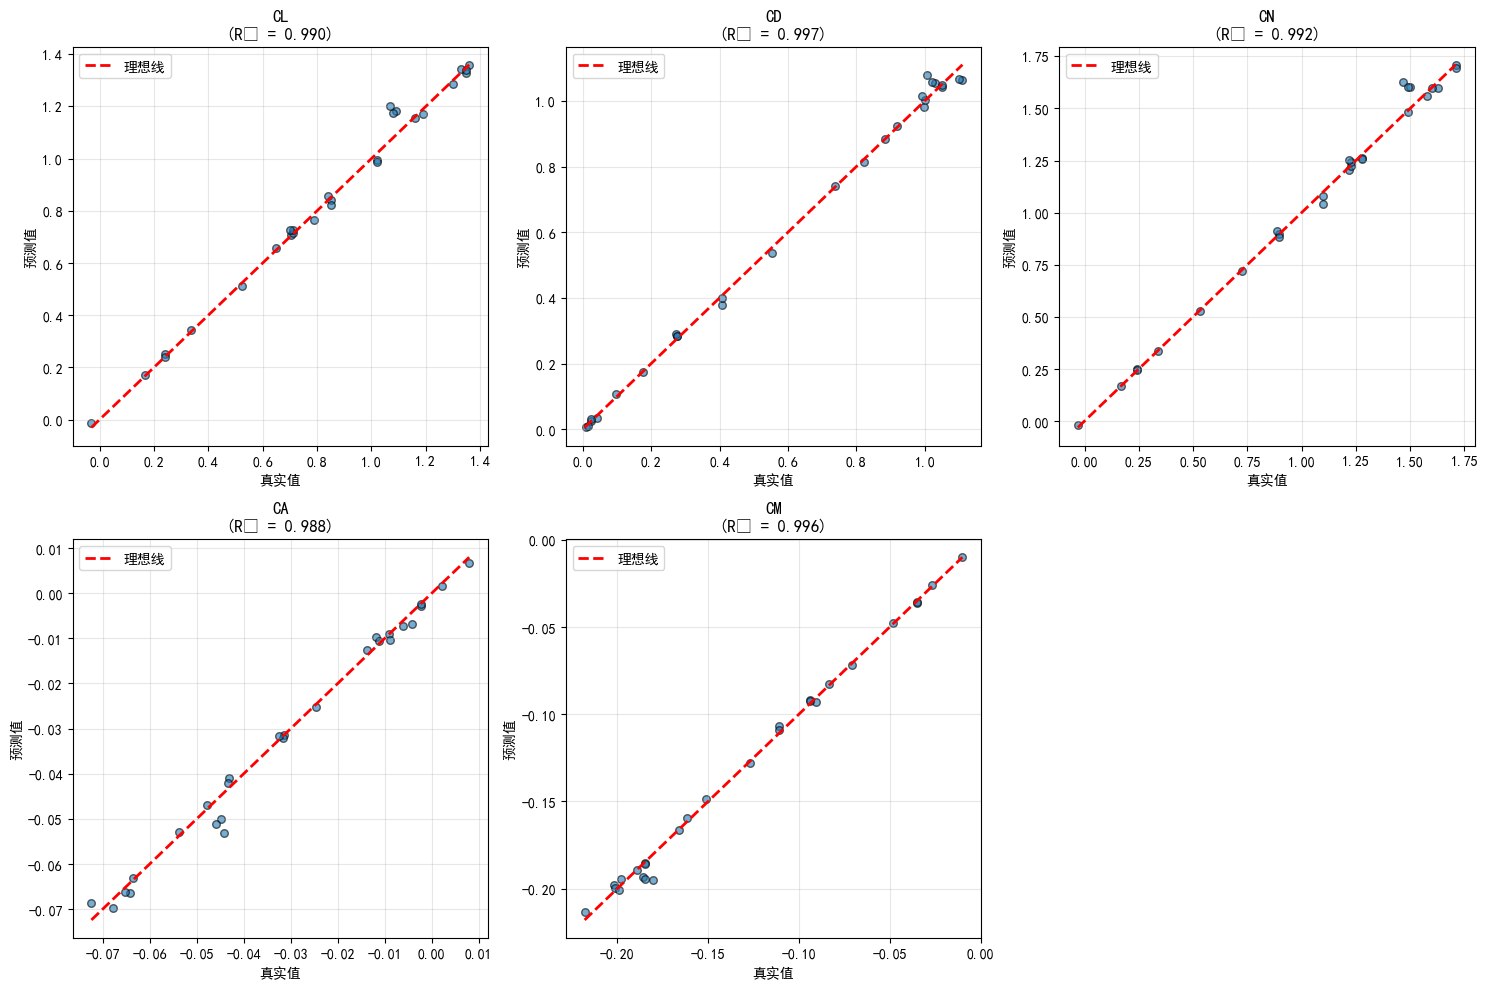

对比图已保存至 xgb_component_comparison.png

XGBoost 对比实验完成！


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

# ==================== 数据加载与预处理 ====================
print("开始加载数据...")
df = pd.read_excel('data_all.xlsx')
feature_columns = ['MA', 'BETA', 'AA']
target_columns = ['CL', 'CD', 'CN', 'CA', 'CM']
X = df[feature_columns].values
y = df[target_columns].values

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)
y_test_scaled = scaler_y.transform(y_test)

# ==================== XGBoost 模型训练（兼容旧版本） ====================
print("\n开始训练 XGBoost 模型...")
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

# 尝试使用 early_stopping_rounds，若失败则使用固定迭代次数
try:
    xgb_model.fit(
        X_train_scaled, y_train_scaled,
        eval_set=[(X_val_scaled, y_val_scaled)],
        early_stopping_rounds=50,
        verbose=False
    )
    print(f"训练完成，最佳迭代轮数: {xgb_model.best_iteration}")
except TypeError:
    # 旧版本不支持 early_stopping_rounds，直接训练固定轮数
    print("当前 XGBoost 版本不支持 early_stopping_rounds，将使用固定 300 轮迭代。")
    xgb_model.fit(X_train_scaled, y_train_scaled, verbose=False)

# ==================== 评估函数 ====================
def evaluate_model(model, X, y_true_scaled, scaler_y):
    y_pred_scaled = model.predict(X)
    y_true_orig = scaler_y.inverse_transform(y_true_scaled)
    y_pred_orig = scaler_y.inverse_transform(y_pred_scaled)

    total_mse = mean_squared_error(y_true_orig, y_pred_orig)
    total_rmse = np.sqrt(total_mse)
    total_mae = mean_absolute_error(y_true_orig, y_pred_orig)
    total_r2 = r2_score(y_true_orig, y_pred_orig)
    mse_loss = np.mean((y_true_orig - y_pred_orig) ** 2)
    mae_loss = np.mean(np.abs(y_true_orig - y_pred_orig))
    total_combined = mse_loss 

    n_outputs = y_true_orig.shape[1]
    component_metrics = {}
    for i in range(n_outputs):
        y_true_i = y_true_orig[:, i]
        y_pred_i = y_pred_orig[:, i]
        rmse_i = np.sqrt(mean_squared_error(y_true_i, y_pred_i))
        mae_i = mean_absolute_error(y_true_i, y_pred_i)
        r2_i = r2_score(y_true_i, y_pred_i)
        epsilon = 1e-8
        mre_i = np.mean(np.abs((y_true_i - y_pred_i) / (np.abs(y_true_i) + epsilon)))
        component_metrics[i] = {'RMSE': rmse_i, 'MAE': mae_i, 'R2': r2_i, 'MRE': mre_i}

    overall_metrics = {
        'MSE': total_mse,
        'RMSE': total_rmse,
        'MAE': total_mae,
        'R2': total_r2,
        'Combined_Loss': total_combined
    }
    return overall_metrics, component_metrics, (y_true_orig, y_pred_orig)

# ==================== 评估 ====================
print("\n===== 测试集评估结果 =====")
test_overall, test_component, (test_true, test_pred) = evaluate_model(xgb_model, X_test_scaled, y_test_scaled, scaler_y)
print(f"总体指标: MSE={test_overall['MSE']:.6f}, RMSE={test_overall['RMSE']:.6f}, MAE={test_overall['MAE']:.6f}, R2={test_overall['R2']:.6f}, Combined={test_overall['Combined_Loss']:.6f}")

print("\n各分量详细指标:")
for i, name in enumerate(target_columns):
    m = test_component[i]
    print(f"{name}: RMSE={m['RMSE']:.6f}, MAE={m['MAE']:.6f}, R2={m['R2']:.6f}, MRE={m['MRE']:.4%}")

print("\n===== 训练集评估 =====")
train_overall, _, _ = evaluate_model(xgb_model, X_train_scaled, y_train_scaled, scaler_y)
print(f"总体RMSE={train_overall['RMSE']:.6f}, R2={train_overall['R2']:.6f}")

print("\n===== 验证集评估 =====")
val_overall, _, _ = evaluate_model(xgb_model, X_val_scaled, y_val_scaled, scaler_y)
print(f"总体RMSE={val_overall['RMSE']:.6f}, R2={val_overall['R2']:.6f}")

# ==================== 可视化 ====================
def plot_true_vs_pred(true, pred, target_names, component_metrics, save_path='xgb_component_comparison.png'):
    n = len(target_names)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    for i, name in enumerate(target_names):
        ax = axes[i]
        ax.scatter(true[:, i], pred[:, i], alpha=0.6, edgecolors='k', s=30)
        min_val = min(true[:, i].min(), pred[:, i].min())
        max_val = max(true[:, i].max(), pred[:, i].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='理想线')
        ax.set_xlabel('真实值')
        ax.set_ylabel('预测值')
        ax.set_title(f'{name}\n(R² = {component_metrics[i]["R2"]:.3f})')
        ax.legend()
        ax.grid(True, alpha=0.3)
    if n < len(axes):
        axes[-1].set_visible(False)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"对比图已保存至 {save_path}")

plot_true_vs_pred(test_true, test_pred, target_columns, test_component, save_path='xgb_component_comparison.png')

print("\nXGBoost 对比实验完成！")